In [15]:
from tqdm.auto import tqdm
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

########################################################   CONSTANTS   ########################################################
SunPower = 1361                                     # Raw power of sunlight when it reaches the satellite in W/m2
BOLSolarCellEfficiency = 0.3                        # Beginning Of Life efficiency of the Solar Cells
EOLSolarCellEfficiency = 0.209                      # End Of Life efficiency of the Solar Cells
BatteryDegradationFittingConstant = 0.0000348       # Curve fitting constant in s^-1/2

####################################################   ITERATING CONSTANTS   ##################################################
# Each value is defined as: value = [minimum, maximum, step]
PanelSurface = [3, 5, 0.2]                          # Effective surface of the Solar Panels (just the surface of the cells)
BOLBatteryCapacity = [600, 1200, 60]                # Initial capacity of the battery in Wh
PowerDraw = [600, 1000, 40]                         # Power drawn by the system 

#######################################################   MAIN PROGRAM   ######################################################
# Import data from csv files
SolarIntensity = pd.read_csv('Solar_intensity.csv')['Intensity']
SunVector = pd.read_csv('sun_vector.csv')[['x (km)', 'y (km)', 'z (km)']]

# Check if the files match dates and times
Times = pd.read_csv('Solar_intensity.csv')[['Time (UTCG)']]
Times = Times.rename(columns={'Time (UTCG)': 'Solar Intensity'})
Times['Sun Vector'] = pd.read_csv('sun_vector.csv')['Time (UTCG)']
Times['Solar Intensity'] = pd.to_datetime(Times['Solar Intensity'])
Times['Sun Vector'] = pd.to_datetime(Times['Sun Vector'])
if (Times['Sun Vector'] != Times['Solar Intensity']).any():
    if len(Times['Sun Vector']) != len(Times['Solar Intensity']):
        raise ValueError('>>> ERROR: Files have different number of rows. Files may be from different simulations')
    else:
        raise ValueError('>>> ERROR: Timestamps are not the same between files. Files may be from different simulations')
    
# Create a timestep for the calculations
Times['Timestep'] = Times['Solar Intensity'].diff().dt.total_seconds().fillna(0)
Times['CumulativeTime'] = Times['Timestep'].cumsum()

# Calculate angles of incidence from each plane
SunVector['X Face Angle'] = np.arcsin(SunVector['x (km)']/(np.sqrt((SunVector['x (km)']**2) + (SunVector['y (km)']**2) + (SunVector["z (km)"]**2))))
SunVector['Y Face Angle'] = np.arcsin(SunVector['y (km)']/(np.sqrt((SunVector['x (km)']**2) + (SunVector['y (km)']**2) + (SunVector["z (km)"]**2))))
SunVector['Z Face Angle'] = np.arcsin(SunVector['z (km)']/(np.sqrt((SunVector['x (km)']**2) + (SunVector['y (km)']**2) + (SunVector["z (km)"]**2))))

# Calculate efficiency of the Solar Cells for the duration of the mission
PanelEfficiency = pd.Series(np.linspace(BOLSolarCellEfficiency, EOLSolarCellEfficiency, num = len(Times['Sun Vector'])))

# Iterate for every panel surface
Generation = {}
for PanelSurfaceIndex in range(int((PanelSurface[1] - PanelSurface[0]) / PanelSurface[2])):
    IterationPanelSurface = PanelSurface[0] + (PanelSurface[2] * PanelSurfaceIndex)

    # Calculate the power generation from each satellite face
    Generation[f'{IterationPanelSurface}m^2'] = pd.DataFrame()
    Generation[f'{IterationPanelSurface}m^2']['W generated in face X'] = SunPower * np.sin(SunVector['X Face Angle']) * PanelEfficiency * IterationPanelSurface * (SolarIntensity/100)
    Generation[f'{IterationPanelSurface}m^2']['W generated in face Y'] = SunPower * np.sin(SunVector['Y Face Angle']) * PanelEfficiency * IterationPanelSurface * (SolarIntensity/100)
    Generation[f'{IterationPanelSurface}m^2']['W generated in face Z'] = SunPower * np.sin(SunVector['Z Face Angle']) * PanelEfficiency * IterationPanelSurface * (SolarIntensity/100)

# Iterate for every BOL Battery Capacity
RealBatteryCapacity = pd.DataFrame()
for BOLBatteryCapacityIndex in range(int((BOLBatteryCapacity[1] - BOLBatteryCapacity[0]) / BOLBatteryCapacity[2])):
    IterationBOLBatteryCapacity = BOLBatteryCapacity[0] + (BOLBatteryCapacity[2] * BOLBatteryCapacityIndex)

    # Calculate the degradation of the battery in each point in time
    RealBatteryCapacity[f'{IterationBOLBatteryCapacity} Wh'] = IterationBOLBatteryCapacity * (1 - (BatteryDegradationFittingConstant * np.sqrt(Times['CumulativeTime'])))

# Iterate every value to calculate charge
Charge = {}
PanelPositions =   [['W generated in face X', 'Panels in face X'],
                    ['W generated in face Y', 'Panels in face Y'],
                    ['W generated in face Z', 'Panels in face Z']]
OutOfBattery = []
for PanelSurfaceIndex in tqdm(range(int((PanelSurface[1] - PanelSurface[0]) / PanelSurface[2])), desc='Loading'):
    IterationPanelSurface = PanelSurface[0] + (PanelSurface[2] * PanelSurfaceIndex)
    Charge[f'{IterationPanelSurface}m^2'] = {}

    for BOLBatteryCapacityIndex in tqdm(range(int((BOLBatteryCapacity[1] - BOLBatteryCapacity[0]) / BOLBatteryCapacity[2])), desc='Battery sizes', leave=False):
        IterationBOLBatteryCapacity = BOLBatteryCapacity[0] + (BOLBatteryCapacity[2] * BOLBatteryCapacityIndex)
        Charge[f'{IterationPanelSurface}m^2'][f'{IterationBOLBatteryCapacity}Wh'] = {}

        for PowerDrawIndex in tqdm(range(int((PowerDraw[1] - PowerDraw[0]) / PowerDraw[2])), desc='Power configs', leave=False):
            IterationPowerDraw = PowerDraw[0] + (PowerDraw[2] * PowerDrawIndex)
            Charge[f'{IterationPanelSurface}m^2'][f'{IterationBOLBatteryCapacity}Wh'][f'{IterationPowerDraw}W'] = pd.DataFrame()

            for PanelPositionIndex in range(3):
                # Calculate state of charge of the battery in each point in time
                Charge[f'{IterationPanelSurface}m^2'][f'{IterationBOLBatteryCapacity}Wh'][f'{IterationPowerDraw}W'][PanelPositions[PanelPositionIndex][1]] = np.nan
                Charge[f'{IterationPanelSurface}m^2'][f'{IterationBOLBatteryCapacity}Wh'][f'{IterationPowerDraw}W'].loc[0, PanelPositions[PanelPositionIndex][1]] = IterationBOLBatteryCapacity
                BatteryDown = 0
                for i in range(len(Times['Sun Vector'])-1):
                    NextValue = Charge[f'{IterationPanelSurface}m^2'][f'{IterationBOLBatteryCapacity}Wh'][f'{IterationPowerDraw}W'][PanelPositions[PanelPositionIndex][1]].iloc[i] + (((Generation[f'{IterationPanelSurface}m^2'][PanelPositions[PanelPositionIndex][0]][i+1] - IterationPowerDraw) * Times['Timestep'][1])/3600)
                    if NextValue > RealBatteryCapacity[f'{IterationBOLBatteryCapacity} Wh'].iloc[i+1]:
                        Charge[f'{IterationPanelSurface}m^2'][f'{IterationBOLBatteryCapacity}Wh'][f'{IterationPowerDraw}W'].loc[i+1, PanelPositions[PanelPositionIndex][1]] = RealBatteryCapacity[f'{IterationBOLBatteryCapacity} Wh'].iloc[i+1]
                    elif NextValue < 0:
                        Charge[f'{IterationPanelSurface}m^2'][f'{IterationBOLBatteryCapacity}Wh'][f'{IterationPowerDraw}W'].loc[i+1, PanelPositions[PanelPositionIndex][1]] = 0
                        if BatteryDown == 0:
                            OutOfBattery.append([f'{IterationPanelSurface}m^2', f'{IterationBOLBatteryCapacity}Wh', f'{IterationPowerDraw}W', PanelPositions[PanelPositionIndex][1]])
                            BatteryDown = 1
                    else:
                        Charge[f'{IterationPanelSurface}m^2'][f'{IterationBOLBatteryCapacity}Wh'][f'{IterationPowerDraw}W'].loc[i+1, PanelPositions[PanelPositionIndex][1]] = NextValue

Loading:   0%|          | 0/10 [00:00<?, ?it/s]

Battery sizes:   0%|          | 0/10 [00:00<?, ?it/s]

Power configs:   0%|          | 0/10 [00:00<?, ?it/s]

Power configs:   0%|          | 0/10 [00:00<?, ?it/s]

Power configs:   0%|          | 0/10 [00:00<?, ?it/s]

...

Power configs:   0%|          | 0/10 [00:00<?, ?it/s]

Power configs:   0%|          | 0/10 [00:00<?, ?it/s]

Power configs:   0%|          | 0/10 [00:00<?, ?it/s]

Power configs:   0%|          | 0/10 [00:00<?, ?it/s]

Power configs:   0%|          | 0/10 [00:00<?, ?it/s]

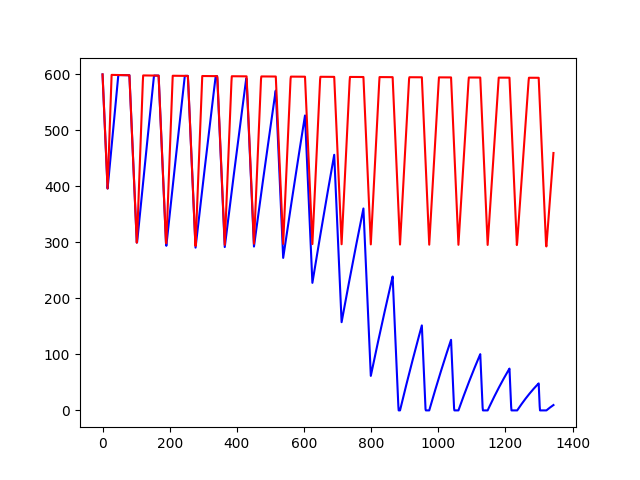

In [16]:
plt.figure("Charge respect time")
plt.title("Charge respect time")
plt.clf()
plt.plot(Charge['3.0m^2']['600Wh']['760W']['Panels in face Y'], color = 'blue')
plt.plot(Charge['4.6m^2']['600Wh']['760W']['Panels in face Y'], color = 'red')
plt.show()

C:\Users\escri\AppData\Local\Temp\ipykernel_20676\3600543896.py:29: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  ax.scatter3D(X, Y, Z, cmap = cm.turbo, linewidth=0, antialiased=False)


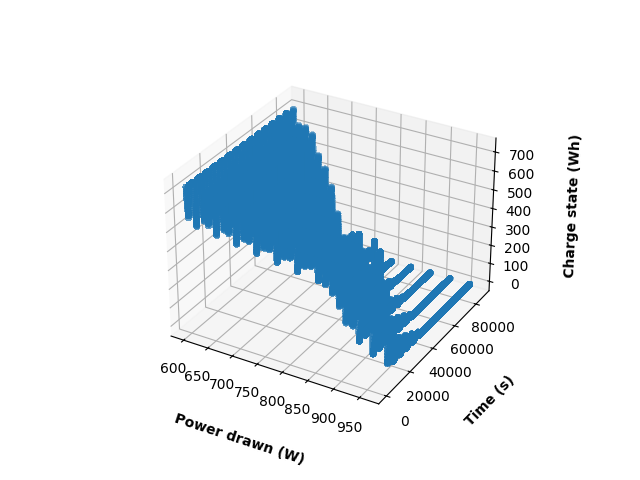

In [23]:
from matplotlib import cm
plt.close()
plt.figure("Charge graph for every power draw")
plt.title("Charge graph for every power draw")
plt.clf()
ax = plt.axes(projection='3d')
ax.set_xlabel('Power drawn (W)', labelpad = 15, fontweight = 'bold')
ax.set_ylabel('Time (s)', labelpad = 15, fontweight = 'bold')
ax.set_zlabel('Charge state (Wh)', labelpad = 15, fontweight = 'bold')

xdata = []
ydata = []

Z = []
for i in range(int((PowerDraw[1] - PowerDraw[0])/PowerDraw[2])):
    Xvalue = PowerDraw[0] + (PowerDraw[2]*i)
    xdata.append(Xvalue)
    temp = []
    for j in range(len(Times['CumulativeTime'])):
        temp.append(Charge['3.0m^2']['720Wh'][f'{Xvalue}W']['Panels in face Y'].iloc[j])
    Z.append(temp)
Z = np.array(Z)
Z = Z.T

ydata = Times['CumulativeTime']

X, Y = np.meshgrid(xdata, ydata)

ax.scatter3D(X, Y, Z, cmap = cm.turbo, linewidth=0, antialiased=False)
plt.show()

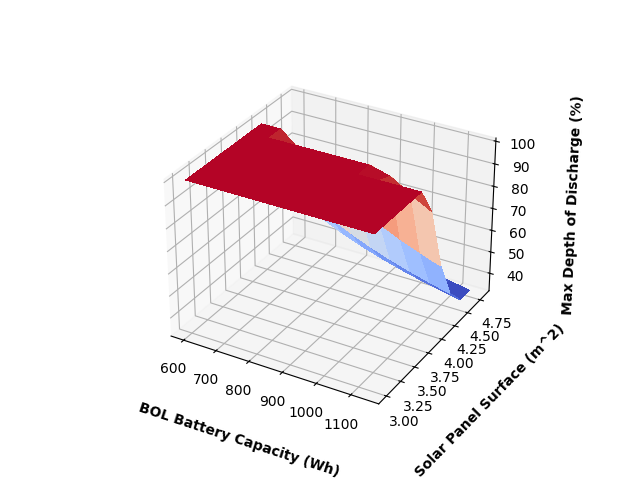

In [22]:
%matplotlib widget
plt.close()
plt.figure("Minimum charge for every panel size and battery size")
plt.clf()
ax = plt.axes(projection='3d')
ax.set_xlabel('BOL Battery Capacity (Wh)', labelpad = 15, fontweight = 'bold')
ax.set_ylabel('Solar Panel Surface (m^2)', labelpad = 15, fontweight = 'bold')
ax.set_zlabel('Max Depth of Discharge (%)', labelpad = 15, fontweight = 'bold')

xdata = []
ydata = []
Z = []

for i in range(int((PanelSurface[1] - PanelSurface[0])/PanelSurface[2])):
    Yvalue = PanelSurface[0] + (PanelSurface[2]*i)
    ydata.append(Yvalue)

for i in range(int((BOLBatteryCapacity[1] - BOLBatteryCapacity[0])/BOLBatteryCapacity[2])):
    Xvalue = BOLBatteryCapacity[0] + (BOLBatteryCapacity[2]*i)
    xdata.append(Xvalue)
    tempZ = []
    for j in range(int((PanelSurface[1] - PanelSurface[0])/PanelSurface[2])):
        Yvalue = PanelSurface[0] + (PanelSurface[2]*j)
        tempZ.append(100-((min(Charge[f'{Yvalue}m^2'][f'{Xvalue}Wh']['920W']['Panels in face Y']))*100/Xvalue))
    Z.append(tempZ)
Z = np.array(Z)
Z = Z.T

X, Y = np.meshgrid(xdata, ydata)

ax.plot_surface(X, Y, Z, cmap = cm.coolwarm, linewidth=0, antialiased=False)
plt.show()